# Statistical Data Analysis - Megaline Prepaid Plan Analysis 

# Which one is a better plan?

Our Megaline prepaid plan analysis will consist of reviewing provided data to clean, compile and study with the focus of answering the question of which plan brings in more revenue and be considered the better telecom plan. 

Megaline has provided data on 500 clients subscribed to one of two plans "surf" or "ultimate" for the year 2018. Data includes client names, user ids, city of residence, registered date, calls made, messages sent, and internet usage in mbs among other details. The particular monthly cost data of each plan was also provided.

Our 500 client sample of data lends its self to analysis in the form of statistical hypothesis t-testing based on a normal distribution of the sample provided.

We will be conducting the study in four stages:
- Data preparation
- Data aggregation 
- User behavior analysis
- Hypothesis testing



## Initialization

To begin we will import the apporiate libraries for this project.

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np 
from math import factorial 
from scipy import stats as st

## Load data

Next we must load our given data into variables.

In [3]:
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

## Prepare the data

We will prepare the data by reviewing if there are any issues to be fixed or factors that might be added making the data easier to analyze. We will look at the dataframes and call `.info` on each set. 

## Plans

In [4]:
display(plans)
print(plans.info())

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


This dataset contains only to rows pertaining to different plans in the Megaline servicer ('surf' and 'ultimate').

There is no need to view a sample of the plans dataset as it only contains two rows.

## Fix data

We can also see from the documentation in the project theory that monthly GB usage for each plan is 15GB and 30GB respectivley. These are not the values present in the dataset, so we will correct them. 

In [5]:
plans['mb_per_month_included'] = plans['mb_per_month_included'].replace(15360, 15000)
plans['mb_per_month_included'] = plans['mb_per_month_included'].replace(30720, 30000)
plans.insert(2, "gb_per_month_included", [15, 30])

## Add feature 

To make the data set more readable we can move the `plan_name` column to be the first and avoid confussion when looking through for values.

In [6]:
plans.set_index(plans.pop('plan_name'), inplace=True)
plans.reset_index(inplace=True)
plans

,plan_name,messages_included,mb_per_month_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,surf,50,15000,15,500,20,10,0.03,0.03
1,ultimate,1000,30000,30,3000,70,7,0.01,0.01


A total of two modifications were done to this dataset as part of preprocessing.  

## Users

In [7]:
display(users)
users.info()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


This data set contains 8 columns and 500 rows with information about each user identified by thier ID's. Data set info shows a total of 34 non-null items in the `churn_date` column (date service stopped), meaning 466 users were still using the service when this data was obtained.

In [8]:
users.sample(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
454,1454,Kymberly,Cohen,56,"San Antonio-New Braunfels, TX MSA",2018-05-30,ultimate,NaN
393,1393,Wilfredo,Rosa,44,"Knoxville, TN MSA",2018-10-29,surf,NaN
400,1400,Kenton,Hickman,72,"Riverside-San Bernardino-Ontario, CA MSA",2018-03-08,surf,NaN
63,1063,Larhonda,Hartman,60,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-05,ultimate,NaN
131,1131,Shane,Morrison,60,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-01-07,surf,NaN
346,1346,Emmie,Gonzalez,59,"Tucson, AZ MSA",2018-04-26,ultimate,NaN
311,1311,Cherlyn,Saunders,69,"Memphis, TN-MS-AR MSA",2018-06-27,ultimate,NaN
174,1174,Larisa,Ellis,67,"Cleveland-Elyria, OH MSA",2018-01-28,surf,NaN
462,1462,Lesley,Workman,20,"Las Vegas-Henderson-Paradise, NV MSA",2018-09-05,ultimate,NaN
428,1428,Asuncion,Conrad,66,"Phoenix-Mesa-Chandler, AZ MSA",2018-10-23,surf,NaN


From the datas information we can see all columns are categorical, however not all have an object format. This might lead to accidental changes in values or grouping.

### Fix Data

We correct the datatypes to objects.

In [9]:
users.astype({'user_id': 'object', 'age': 'object'}).dtypes

user_id       object
first_name    object
last_name     object
age           object
city          object
reg_date      object
plan          object
churn_date    object
dtype: object

We will also check for duplicates.

In [10]:
print("Number of duplicates:", users.duplicated().sum())

Number of duplicates: 0


### Add Feature

We will also convert both `reg_date` and `churn_date` into `datetime` for more flexability when conducting analysis. We must coerce errors in `churn_date` to ignore missing values.

In [11]:
users['reg_date'] = pd.to_datetime(users['reg_date'], format= '%Y-%m-%d')
users['churn_date'] = pd.to_datetime(users['churn_date'], format= '%Y-%m-%d', errors='coerce')
users.dtypes

user_id                int64
first_name            object
last_name             object
age                    int64
city                  object
reg_date      datetime64[ns]
plan                  object
churn_date    datetime64[ns]
dtype: object

A total of two modifications were done to this dataset as part of preprocessing.  

## Calls

In [12]:
display(calls)
calls.info()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72
137731,1499_200,1499,2018-10-20,10.89
137732,1499_201,1499,2018-09-21,8.12
137733,1499_202,1499,2018-10-10,0.37


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


This data set displays information concerning date and call duration of each call made by users. There are no null values in this data set.

In [13]:
calls.sample(10)

,id,user_id,call_date,duration
43848,1159_444,1159,2018-08-16,15.06
29187,1110_238,1110,2018-12-05,5.46
132326,1476_272,1476,2018-09-04,5.34
43201,1157_230,1157,2018-10-02,0.00
69418,1249_246,1249,2018-08-14,0.99
53929,1195_99,1195,2018-10-09,3.15
114122,1400_471,1400,2018-11-26,0.00
121468,1427_136,1427,2018-08-24,19.08
17907,1068_233,1068,2018-09-30,4.00
36656,1139_23,1139,2018-12-17,4.99


There are no apparent issues with this data set, we can however correct some datatypes and check for other non-apparnet issues such as duplicates.

### Fix data

Convert `call_date` to `datetime`.

In [14]:
calls['user_id'] = calls['user_id'].astype('object')
calls['call_date'] = pd.to_datetime(calls['call_date'], format= '%Y-%m-%d')
calls.dtypes

id                   object
user_id              object
call_date    datetime64[ns]
duration            float64
dtype: object

Check for duplicates.

In [15]:
print("Number of duplicates:", calls.duplicated().sum())

Number of duplicates: 0


### Add Feature

No additional factors to be added for now.

## Messages

In [16]:
display(messages)
messages.info()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
...,...,...,...
76046,1497_526,1497,2018-12-24
76047,1497_536,1497,2018-12-24
76048,1497_547,1497,2018-12-31
76049,1497_558,1497,2018-12-24


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


This data set contains 3 columns with 76051 rows and indentifies each message made by users with an ID number. The dataset info shows no null values.

In [17]:
messages.sample(10)

,id,user_id,message_date
46671,1318_43,1318,2018-11-14
5732,1054_99,1054,2018-08-10
48589,1326_126,1326,2018-07-23
24046,1144_551,1144,2018-08-08
8532,1062_16,1062,2018-08-19
55676,1349_630,1349,2018-10-03
59534,1379_11,1379,2018-12-15
40723,1261_383,1261,2018-05-17
46648,1318_10,1318,2018-12-20
18955,1123_24,1123,2018-11-19


Data sample seems to be in order except for datatypes displayed in info.

### Fix data

Correct datatypes.

In [18]:
messages['user_id'] = messages['user_id'].astype('object')
messages['message_date'] = pd.to_datetime(messages['message_date'], format= '%Y-%m-%d')

Check for duplicates.

In [19]:
print("Number of duplicates:", messages.duplicated().sum())

Number of duplicates: 0


## Internet

In [20]:
display(internet)
internet.info()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06
104821,1499_216,1499,2018-12-30,304.72
104822,1499_217,1499,2018-09-22,292.75
104823,1499_218,1499,2018-12-07,0.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


This dataset contains 4 columns with 104825 rows. It identifies internet sessions by ID and mb usage of each session. Info shows no null values are present.

In [21]:
internet.sample(10)

,id,user_id,session_date,mb_used
13929,1065_25,1065,2018-09-26,242.85
14230,1066_120,1066,2018-10-13,407.35
21623,1099_377,1099,2018-10-09,358.36
31313,1144_6,1144,2018-10-13,1025.22
35046,1157_133,1157,2018-09-24,0.00
29815,1138_41,1138,2018-08-09,231.68
73859,1346_446,1346,2018-07-28,25.73
91242,1420_135,1420,2018-11-18,570.03
85892,1400_20,1400,2018-05-28,212.78
113,1001_211,1001,2018-12-20,273.02


Data sample shows some datatypes should be changed. Sample also shows some users used 0 mb in some sessions, this might cause errors in analysis.

### Fix data

Correct datatypes.

In [22]:
internet['user_id'] = internet['user_id'].astype('object')
internet['session_date'] = pd.to_datetime(internet['session_date'], format = '%Y-%m-%d')

Check for duplicates.

In [23]:
print("Number of duplicates:", internet.duplicated().sum())

Number of duplicates: 0


## Study plan conditions

When studying the plan conditions, we can see both Megaline plans consist of a base monthly pay that includes a certain call, message and GB usage limit. Every user recieves additional charges to the base charge if the limit usages of the plan are exceeded. We will review what each package includes, their base cost and the additional charges per package.

In [24]:
plans

,plan_name,messages_included,mb_per_month_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,surf,50,15000,15,500,20,10,0.03,0.03
1,ultimate,1000,30000,30,3000,70,7,0.01,0.01


## Aggregate data per user

We will begin data aggregation by first calculating the total number of minutes, messages and mb each per month per user. To do this will group each dataset by `user_id`/`month` and either call `count` or `sum` on the variable of interest for each set.

In [25]:
calls_per_user_month = calls.groupby(['user_id', calls.call_date.dt.month])['id'].count().reset_index()

calls_per_user_month.columns = ['user_id', 'month', 'total_calls']
calls_per_user_month

,user_id,month,total_calls
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64
...,...,...,...
2253,1498,12,39
2254,1499,9,41
2255,1499,10,53
2256,1499,11,45


In [50]:
calls['duration'] = np.ceil(calls['duration'])
minutes_per_month = calls.groupby(['user_id', calls.call_date.dt.month])['duration'].sum().reset_index()
minutes_per_month.columns = ['user_id', 'month', 'total_min']
minutes_per_month

,user_id,month,total_min
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0
...,...,...,...
2253,1498,12,339.0
2254,1499,9,346.0
2255,1499,10,385.0
2256,1499,11,308.0


In [27]:
messages_per_month =  messages.groupby(['user_id', messages.message_date.dt.month])['id'].count().reset_index()
messages_per_month.columns = ['user_id', 'month', 'total_messages']
messages_per_month

,user_id,month,total_messages
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


In [28]:
mb_per_month = internet.groupby(['user_id', internet.session_date.dt.month])['mb_used'].sum().reset_index()
mb_per_month.columns = ['user_id', 'month', 'total_mb']
mb_per_month['total_mb'] = np.ceil(mb_per_month['total_mb'])
mb_per_month

,user_id,month,total_mb
0,1000,12,1902.0
1,1001,8,6920.0
2,1001,9,13315.0
3,1001,10,22331.0
4,1001,11,18505.0
...,...,...,...
2272,1498,12,23138.0
2273,1499,9,12985.0
2274,1499,10,19493.0
2275,1499,11,16814.0


Next we will merge the all datasets into a complete monthly usage dataset per user. The data is merged on `user_id`/`month` as these are the columns the datasets are previously grouped by and represents how we are interested in viewing the data. As we are only working with 4 sets we can merge the sets on to each other.

In [29]:
calls_min = pd.merge(calls_per_user_month, minutes_per_month, on = ['user_id', 'month'], how = 'outer')
messages_internet = pd.merge(messages_per_month, mb_per_month, on = ['user_id', 'month'], how = 'outer')
total_monthly_data = pd.merge(calls_min, messages_internet, on = ['user_id', 'month'], how = 'outer')

total_monthly_data 

,user_id,month,total_calls,total_min,total_messages,total_mb
0,1000,12,16.0,116.83,11.0,1902.0
1,1001,8,27.0,171.14,30.0,6920.0
2,1001,9,49.0,297.69,44.0,13315.0
3,1001,10,65.0,374.11,53.0,22331.0
4,1001,11,64.0,404.59,36.0,18505.0
...,...,...,...,...,...,...
2288,1349,12,NaN,NaN,61.0,13040.0
2289,1361,5,NaN,NaN,2.0,1520.0
2290,1482,10,NaN,NaN,2.0,NaN
2291,1108,12,NaN,NaN,NaN,234.0


We now need to view what plan each user is subscribed to in our merged dataset to work out particular insights. We can merge the plan subscribed plan for each user from the `users` dataset.

In [30]:
monthly_usage_data = pd.merge(total_monthly_data, users, on = ['user_id'])
monthly_usage_data['month'] = monthly_usage_data['month'].astype('object')

monthly_usage_data

,user_id,month,total_calls,total_min,total_messages,total_mb,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,12,16.0,116.83,11.0,1902.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,8,27.0,171.14,30.0,6920.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1001,9,49.0,297.69,44.0,13315.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
3,1001,10,65.0,374.11,53.0,22331.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
4,1001,11,64.0,404.59,36.0,18505.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1204,12,NaN,NaN,78.0,36731.0,Sherly,Levy,44,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-08-20,ultimate,NaT
2289,1349,10,NaN,NaN,76.0,13094.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaT
2290,1349,11,NaN,NaN,72.0,17129.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaT
2291,1349,12,NaN,NaN,61.0,13040.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaT


Finally we will write a function that calculates monthly revenue for each user. There are several steps to writing this function. 
- There must first be a variable that equates the users plan subscription to the correct plan information in the `plans` dataset. 
- We then write a series of if statments for each service included in the plans to calculate the additional costs: Each statement is validated if the monthly usage exceeds the usage limit. If it does, obtains the diference between the total usage and monthly limit and mutliplies it by the cost per exceeding. 
- We add all service charges to calculate the additional charges per user.
- Finally we add these additional charges to the base monthly charge of each plan. 

Note* To calculate monthly internet usage we must convert mb used into gb used as specified in the documentation.
We specify axis when applying the function so it may be applied across rows.

We create a new column the our merged dataset with the applied function.

In [31]:
def monthly_charge(row):
    plan_row = plans[plans['plan_name'] == row['plan']]
    
    call_charge = 0 
    message_charge = 0
    internet_charge = 0
    
    if row['total_min'] > plan_row['minutes_included'].values[0]:
        call_charge = (row['total_min'] - plan_row['minutes_included'].values[0]) * plan_row['usd_per_minute'].values[0]
    
    if row['total_messages'] > plan_row['messages_included'].values[0]:
        messages_charge = (row['total_messages'] - plan_row['messages_included'].values[0]) * plan_row['usd_per_message'].values[0]
    
    excess_mb = row['total_mb'] - plan_row['mb_per_month_included'].values[0]
    if excess_mb > 0:
        internet_charge = (excess_mb / 1024) * plan_row['usd_per_gb'].values[0]
    
    additional_charges = call_charge + message_charge + internet_charge
    
    total_monthly_charge = additional_charges + plan_row['usd_monthly_pay'].values[0]

    return total_monthly_charge

monthly_usage_data['monthly_revenue'] = monthly_usage_data.apply(monthly_charge, axis=1)
display(monthly_usage_data)

,user_id,month,total_calls,total_min,total_messages,total_mb,first_name,last_name,age,city,reg_date,plan,churn_date,monthly_revenue
0,1000,12,16.0,116.83,11.0,1902.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,70.000000
1,1001,8,27.0,171.14,30.0,6920.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,20.000000
2,1001,9,49.0,297.69,44.0,13315.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,20.000000
3,1001,10,65.0,374.11,53.0,22331.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,91.591797
4,1001,11,64.0,404.59,36.0,18505.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,54.228516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1204,12,NaN,NaN,78.0,36731.0,Sherly,Levy,44,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-08-20,ultimate,NaT,116.012695
2289,1349,10,NaN,NaN,76.0,13094.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaT,20.000000
2290,1349,11,NaN,NaN,72.0,17129.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaT,40.791016
2291,1349,12,NaN,NaN,61.0,13040.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaT,20.000000


The result is a 14 column dataset containing all usage across services per user by month, inculding monthly revenue. This compiled dataset should ease analysis of user behavior.

## Study user behaviour

Tp properly analyze the data on a per plan basis we will first store plan data in separate variables that grouped by month and obtain the mean for our different variables of interest. To simplify obtaining overall stats on each service provided we will create a function that takes our grouped variables and obtaines the desired stats on the specified column.

In [32]:
surf_data = monthly_usage_data.query("plan == 'surf'").groupby('month')[['total_min', 'total_messages', 'total_mb', 'monthly_revenue']].mean().reset_index()
ultimate_data = monthly_usage_data.query("plan == 'ultimate'").groupby('month')[['total_min', 'total_messages', 'total_mb', 'monthly_revenue']].mean().reset_index()

def data_stats(data):
    surf_mean = surf_data[data].mean()
    ultimate_mean = ultimate_data[data].mean()
    surf_var = surf_data[data].var()
    ultimate_var = ultimate_data[data].var()
    surf_std = surf_data[data].std()
    ultimate_std = ultimate_data[data].std()
    
    print("Surf mean:", surf_mean)
    print("Ultimate mean:", ultimate_mean)
    print()
    print("Surf variance:", surf_var)
    print("Utimate variance:", ultimate_var)
    print()
    print("Surf std:", surf_std)
    print("Ultimate std:", ultimate_std)

### Calls

We will use are grouped plan variables to plot different comparative charts to get a visual understanding of the plan data per month. First we will plot a bar-chart comparing the plans call duration per month.

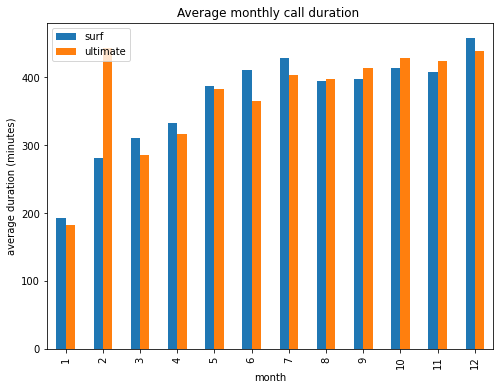

In [33]:
monthly_average_min = pd.merge(surf_data[['month','total_min']], ultimate_data[['month','total_min']], on = 'month')
monthly_average_min['month'] = monthly_average_min['month'].astype('object')
monthly_average_min.columns = ['month', 'surf', 'ultimate']

monthly_average_min.plot(x='month', kind='bar',
                           title="Average monthly call duration ",
                           ylabel="average duration (minutes)",
                           figsize=(8,6))

plt.legend(['surf', 'ultimate'])
plt.show()

Our chart shows call minutes used each month per plan do not vary much from each other except during the three first months of the year. The chart also shows peak usage of minutes used occur during february and december for ultimate and surf respectively. 

We now plot a histogram of the frequency of months that display call duration minutes.

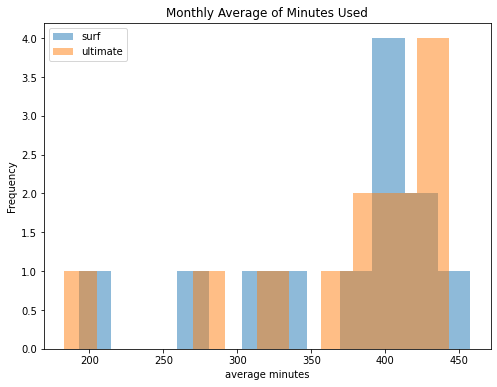

In [34]:
surf_data['total_min'].plot(kind='hist', title="Monthly Average of Minutes Used", bins=12, alpha=0.5, figsize=(8,6))
ultimate_data['total_min'].plot(kind='hist', title="Monthly Average of Minutes Used", bins=12, alpha=0.5, figsize=(8,6))

plt.xlabel("average minutes")
plt.legend(['surf', 'ultimate'])
plt.show()

Our histogram shows ultimate plan minutes in the range of 450 minutes are generaly used more through the year with months in the frequency of 4. Surf plan minutes on the other hand stay around 400 minutes with a frequncy of 3.5.

We use our custom function `data_stats` to obtain the mean, variance and standard deviation of the call duration.

In [35]:
print("Monthly call duration stats:")
print()
data_stats('total_min')

Monthly call duration stats:

Surf mean: 367.95890750535744
Ultimate mean: 373.6460944732439

Surf variance: 5636.603596037749
Utimate variance: 5925.107083650145

Surf std: 75.07731745366073
Ultimate std: 76.97471717161515


Our obtained statistics for the data seem to match our ploted data by showing the overall average of minutes used between plans appears to not vary greatly.  

Now we plot a box-chart of the monthly call distribution.

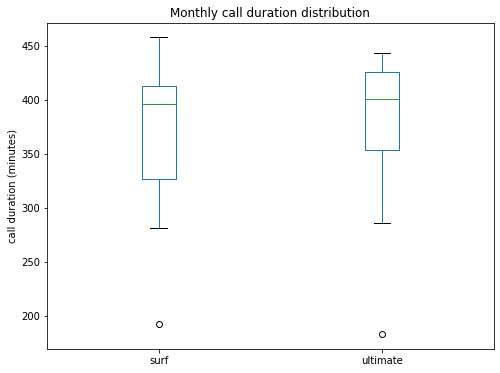

In [36]:
monthly_average_min.boxplot(column=['surf', 'ultimate'],
                            grid=False,
                            figsize=(8,6))

plt.ylabel("call duration (minutes)")
plt.title("Monthly call duration distribution",)
plt.show()

The charts shows upper quartiles of minutes used in both plans are in the range of 420 minutes or above while their median lies around 405 min. Ultimate plan minutes displays an outlier below 200 minutes. Weather or not this outlier can affect the data remains to be seen.

The call duration statistics appear to show no large variance in minutes used across months, however this data is not yet sufficient to draw meaningful conclusions. The prescence of outlier data in the box-chart show that other potential outliers may be present in other metrics. 

### Messages

We will use the same process of plot comparison between data on our other metrics of interest.

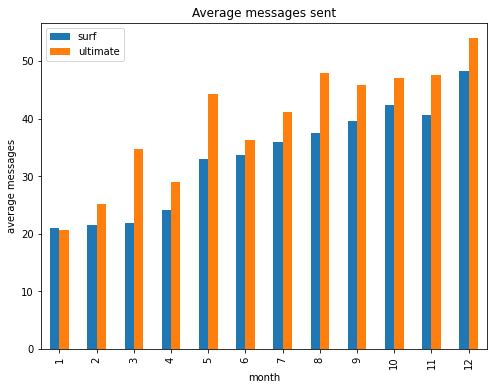

In [37]:
monthly_average_messages = pd.merge(surf_data[['month','total_messages']], ultimate_data[['month','total_messages']], on = 'month')
monthly_average_messages['month'] = monthly_average_min['month'].astype('object')
monthly_average_messages.columns = ['month', 'surf', 'ultimate']

monthly_average_messages.plot(x='month', kind='bar',
                           title="Average messages sent",
                           ylabel="average messages",
                           figsize=(8,6))

plt.legend(['surf', 'ultimate'])
plt.show()

Our plot shows that on a monthly basis users of "ultimate" plan usually send more messages. Messages for both plan users seems to steadly increase accross the year peaking at december for both plans.

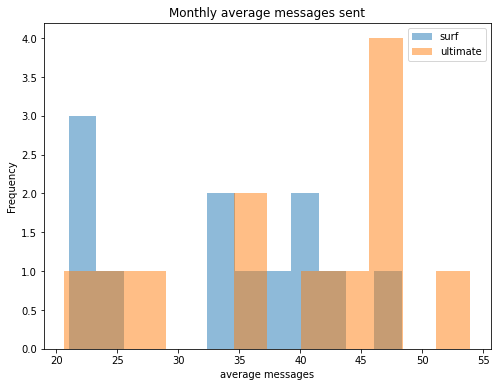

In [38]:
surf_data['total_messages'].plot(kind='hist', title="Monthly average messages sent", bins=12, alpha=0.5, figsize=(8,6))
ultimate_data['total_messages'].plot(kind='hist', title="Monthly average messages sent", bins=12, alpha=0.5, figsize=(8,6))

plt.xlabel("average messages")
plt.legend(['surf', 'ultimate'])
plt.show()

Plotted histogram shows that frequency of months is highest were approximatley 46 messages were sent for the "ultimate" plan. There were more months were approximately 23 messages were sent for the "surf" plan.

In [39]:
print("Monthly messages stats:")
print()
data_stats('total_messages')

Monthly messages stats:

Surf mean: 33.30976679539808
Ultimate mean: 39.47232523405716

Surf variance: 84.26436783310633
Utimate variance: 106.65535848341665

Surf std: 9.179562507718238
Ultimate std: 10.32740812030863


Ultiamte plan messages display greater variance, standard deviation and overall average messages sent than the "surf" plan.

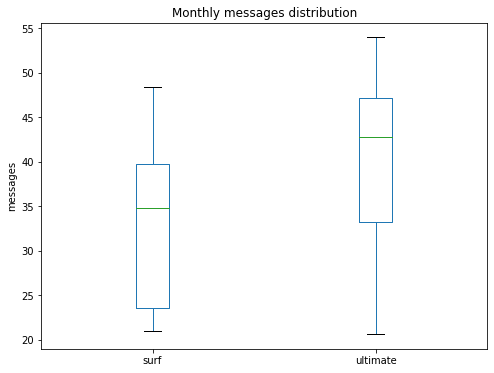

In [40]:
 monthly_average_messages.boxplot(column=['surf', 'ultimate'],
                            grid=False,
                            figsize=(8,6))

plt.ylabel("messages")
plt.title("Monthly messages distribution",)
plt.show()

The monthly messages sent box plot data matches previous data suggesting "ultimate" plan mean to be at around 43 messages per month with an over all range of 21 to 54 messages sent. Surf plan messages display a mean of 35 messages and range from 21 to 48 messages sent.

### Internet

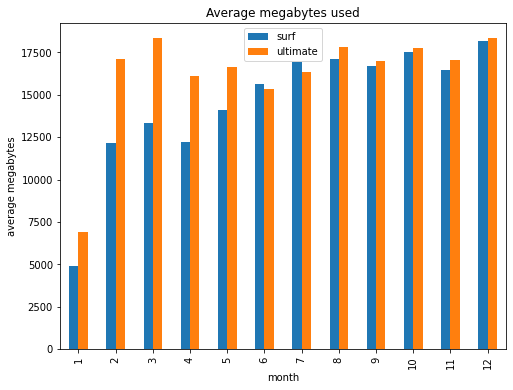

In [41]:
monthly_average_mb = pd.merge(surf_data[['month','total_mb']], ultimate_data[['month','total_mb']], on = 'month')
monthly_average_mb['month'] = monthly_average_min['month'].astype('object')
monthly_average_mb.columns = ['month', 'surf', 'ultimate']

monthly_average_mb.plot(x='month', kind='bar',
                           title="Average megabytes used",
                           ylabel="average megabytes",
                           figsize=(8,6))

plt.legend(['surf', 'ultimate'])
plt.show()

Internet usages bar chart shows megabytes used for both plans increase steadly through the year, with mb usage between plans exhibiting similar numbers. Months February and March for the "ultimate" plan however, show a much higher usage rate than "surf". 

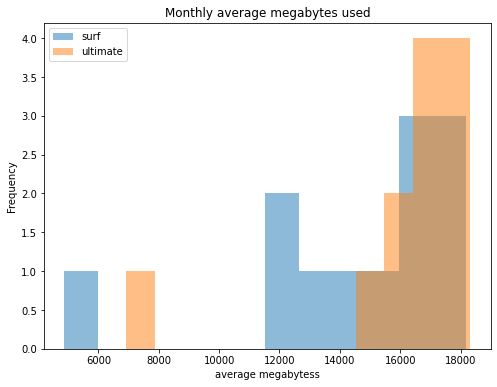

In [42]:
surf_data['total_mb'].plot(kind='hist', title="Monthly average megabytes used", bins=12, alpha=0.5, figsize=(8,6))
ultimate_data['total_mb'].plot(kind='hist', title="Monthly average megabytes used", bins=12, alpha=0.5, figsize=(8,6))

plt.xlabel("average megabytess")
plt.legend(['surf', 'ultimate'])
plt.show()

Histogram data shows frequncy of months is highest were usage is between 16000 mb and 18000 mb.

In [43]:
print("Monthly megabytes stats:")
print()
data_stats('total_mb')

Monthly megabytes stats:

Surf mean: 14605.716532173312
Ultimate mean: 16227.071857336492

Surf variance: 13625452.401469566
Utimate variance: 9396484.081176937

Surf std: 3691.2670455372863
Ultimate std: 3065.3685065872482


Stats for interenet usage show "ultimate" plan has higher mb usage over all.

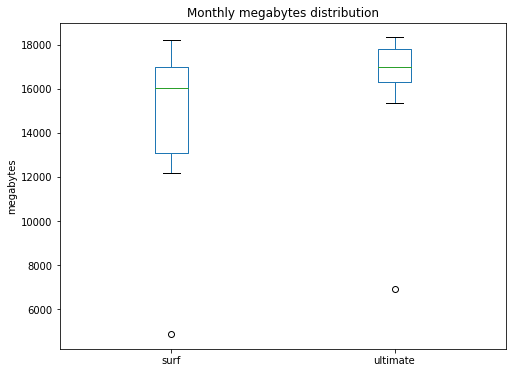

In [44]:
 monthly_average_mb.boxplot(column=['surf', 'ultimate'],
                            grid=False,
                            figsize=(8,6))

plt.ylabel("megabytes")
plt.title("Monthly megabytes distribution",)
plt.show()

Boxplot of internet usage shows "surf" plan displays a wider range of mb used per month while "ultimate" mb usage consistently stays around 15800 to 18000 mb per month. Matching the our barchart, internet usage shows two potential outliers on each tail each of range. These two outliers could potentialy affect data and deserve further study.

## Revenue

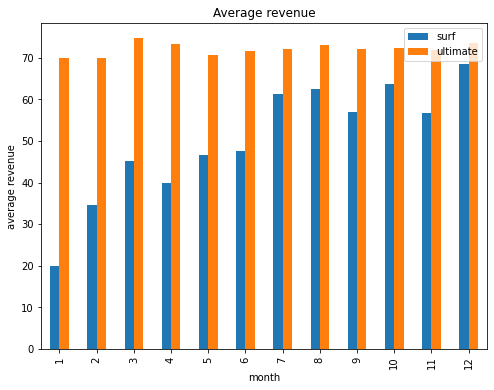

In [45]:
monthly_average_revenue = pd.merge(surf_data[['month','monthly_revenue']], ultimate_data[['month','monthly_revenue']], on = 'month')
monthly_average_revenue['month'] = monthly_average_min['month'].astype('object')
monthly_average_revenue.columns = ['month', 'surf', 'ultimate']

monthly_average_revenue.plot(x='month', kind='bar',
                           title="Average revenue",
                           ylabel="average revenue",
                           figsize=(8,6))

plt.legend(['surf', 'ultimate'])
plt.show()

Plotted monthly revenue barchart shows base monthly pay of 70 dls is generally not exceeded by "ultimate" plan users except for the month of march. Surf users on the otherhand seem to excceed base pay of 20 dls increasingly throughout the year.

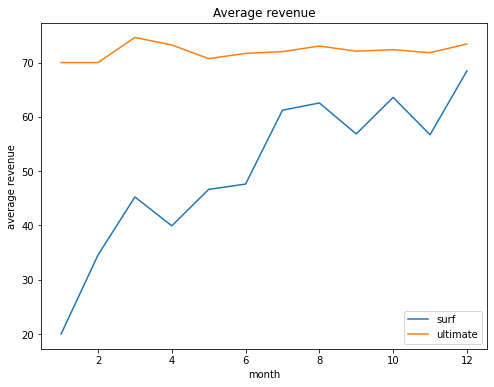

In [46]:
monthly_average_revenue = pd.merge(surf_data[['month','monthly_revenue']], ultimate_data[['month','monthly_revenue']], on = 'month')
monthly_average_revenue['month'] = monthly_average_min['month'].astype('object')
monthly_average_revenue.columns = ['month', 'surf', 'ultimate']

monthly_average_revenue.plot(x='month', kind='line',
                           title="Average revenue",
                           ylabel="average revenue",
                           figsize=(8,6))

plt.legend(['surf', 'ultimate'])
plt.show()

A line chart visualizes our conclusion even better showing consistency in "ultimate" plan revenue and steady increase of revenue for the "surf" plan that exceeds base pay.

In [47]:
print("Monthly revenue stats:")
print()
data_stats('monthly_revenue')

Monthly revenue stats:

Surf mean: 50.279369039134174
Ultimate mean: 72.08772985094903

Surf variance: 198.23811104916115
Utimate variance: 1.9407815398353223

Surf std: 14.07970564497572
Ultimate std: 1.393119355918696


Based on the obatined data for revenue we can see that the base pay of "ultimate" plan results in a greater monthly revenue than for the "surf" plan. A greater degree of revenue variance however, is seen in the "surf" plan.

## Test statistical hypotheses

The primary focus of our data analysis is concerned with studying which megaline plan "surf" or "ultimate" brings in more revenue on a per month basis. We can look at our Monthly revenue stats for some general insight which seems to indicate that the "ultimate" plan usually provides megaline with more revenue.

To be more precise with our answer however we test the hypothesis that the average revenue for both plans is actually different. For this scenario we will test the equality of the average revenue for both plans where:

 - null hypothesis: surf monthly revenue = ultimate monthly revenue
 - alterantive hypothesis: surf monthly revenue != ultimate monthly revenue
 
We will conduct a t-test of our sample data using a statistical significance level of 0.05 provided that the probability of obatining the same average revenue in a month for both plan must be less than the alpha. We will set `equal_var=False` as a parameter as we have no reason to believe that the variances for compared means are similar.

In [48]:
revenue_equality_test = st.ttest_ind(surf_data['monthly_revenue'], ultimate_data['monthly_revenue'], equal_var=False)
alpha = 0.05

print("p-value:", revenue_equality_test.pvalue)
print()

if revenue_equality_test.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We cannot reject the null hypothesis")      

p-value: 0.00022238846369343075

We reject the null hypothesis


Our equality t-test has yielded a p-value of 0.00 and so we may reject the null hypothesis. We can say with more confidence that the revenues obtained per month by plan are different, however further testing is required for more insights as to why this is.

We will use the previous method to test the hypothesis that average revenue in the NY-NJ area is different from all other regions. The regions of interest must first be filtered out in order to conduct this test. In this test:

- null hypothesis: NY-NJ revenue = general regions revenue
- alternative hypothesis: NY-NJ revenue != general regions revenue

In [49]:
NY_NJ_revenue = monthly_usage_data.query("city == 'New York-Newark-Jersey City, NY-NJ-PA MSA'").groupby('month')['monthly_revenue'].mean().reset_index()
genreal_regions_revenue = monthly_usage_data.query("city != 'New York-Newark-Jersey City, NY-NJ-PA MSA'").groupby('month')['monthly_revenue'].mean().reset_index()

city_revenue_equality_test = st.ttest_ind(NY_NJ_revenue['monthly_revenue'], genreal_regions_revenue['monthly_revenue'])

alpha = 0.05

print("p-value:", city_revenue_equality_test.pvalue)
print()

if city_revenue_equality_test.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We cannot reject the null hypothesis")    

p-value: 0.05896152308043387

We cannot reject the null hypothesis


The test has yielded a p-value of 0.058 which is barely outside our significance level. Therefore we will cannot reject the null hytpothesis that revenue on any given month for both regions is the same.

## General conclusion

Our study of the provided data suggested that in order to properly draw insights concerning usage and revenue the data had to be analyzed per month and by plan. To achieve this we aggregated data to single dataset that would help filter variables of concern. Our complied data is then able to be tested for inquiries concerning monthly revenue.

The provided Megaline data for plans "surf" and "ultimate" show:

- Across most months usage of calls, messages and interent appear to be higher for the "ultimate" plan according to plotted figures.
- There are outliers present in both call duration and mb usage, however mb usage displays a wider range of possible outliers.
- Usage of services appear to increase monthly thoughout the year for "surf" plan users.
- Revenue for the "ultimate" plan appears to be greater per month than for the "surf" plan, according to stats obtained. 
- There is greater variance and standard deviation in monthly revenue for "surf" plan users. This average results in 5dls above the monthly base pay than for "ultimate" plan users and for "ultiamte users"
- t-test for monthly revenue equality reveal a 0% chance of revenues being the same for both plans on any given month. 
- The t-test result as well as the ploted data and stats leads us to conclude that the "ultimate" plan does in fact generate more revenue than the "surf" plan.

The insights gained shed usefull information for potential decisions regarding megaline plan modification. The study also rasises many questions as to why the data shows certain figures. Is higher revenue for the "ultimate" plan due to the base pay being higher? Based on the stats what service usage limites can be optimized to generate greater revenue? Is greater variance in "surf" revenue due to users exceding the plan limits easier? By continuing to study the data thourgh filtering, comparision and hypothesis testing we may answer some of the questions posed by our study. 